# NOTEBOOK 04: KỸ THUẬT TẠO ĐẶC TRƯNG (FEATURE ENGINEERING)

### Mục tiêu
Notebook này thực hiện quy trình kỹ thuật tạo đặc trưng (Feature Engineering - FE) cho mô hình dự đoán thất bại của các nghiên cứu lâm sàng. Quy trình được thực hiện theo đúng chuẩn thực hành tốt nhất trong khoa học dữ liệu:

- **Tập huấn luyện (Train)**: Thực hiện `fit` (học các tham số) và `transform` (chuyển đổi dữ liệu)
- **Tập xác thực (Validation)**: Chỉ thực hiện `transform` (sử dụng tham số đã học từ tập train)
- **Tập kiểm tra (Test)**: Chỉ thực hiện `transform` (sử dụng tham số đã học từ tập train)

### Nguyên tắc chống Data Leakage
Việc tách biệt quy trình `fit` và `transform` là yếu tố quan trọng để tránh hiện tượng rò rỉ dữ liệu (data leakage). Các tham số như giá trị trung bình, độ lệch chuẩn, mapping categories đều phải được tính toán chỉ trên tập train, sau đó áp dụng lên tập validation và test.

### Cấu trúc Notebook
1. Thiết lập môi trường và thư viện
2. Tải dữ liệu từ thư mục modeling
3. Tạo đặc trưng (Feature Engineering)
4. Chuẩn hóa đặc trưng (Feature Scaling)
5. Phân tích tương quan
6. Lưu trữ dữ liệu và tham số
7. Tổng kết và kết luận

## 1. Thiết lập Môi trường và Thư viện

Các thư viện được sử dụng:
- **pandas, numpy**: Xử lý và thao tác dữ liệu
- **scikit-learn**: Các công cụ chuẩn hóa
- **matplotlib, seaborn**: Trực quan hóa dữ liệu
- **src.data.feature_engineering**: Module Feature Engineering tự xây dựng

In [1]:
import sys
import warnings
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.feature_engineering import FeatureEngineer, FeatureScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELING_DIR = PROCESSED_DIR / "modeling"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "model_results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("THIẾT LẬP MÔI TRƯỜNG")
print(f"Project root: {PROJECT_ROOT}")
print(f"Modeling directory: {MODELING_DIR}")

THIẾT LẬP MÔI TRƯỜNG
Project root: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction
Modeling directory: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/processed/modeling


/home/lang-phu-quy/miniconda3/envs/jupyter_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Tải Dữ liệu từ Thư mục Modeling

Dữ liệu đã được chia thành 3 tập:
- **Train set**: Dùng để huấn luyện và `fit` các transformer
- **Validation set**: Dùng để tinh chỉnh siêu tham số
- **Test set**: Dùng để đánh giá cuối cùng

In [2]:
print("TẢI DỮ LIỆU TỪ THƯ MỤC MODELING")

train_df = pd.read_csv(MODELING_DIR / "train_data.csv")
val_df = pd.read_csv(MODELING_DIR / "val_data.csv")
test_df = pd.read_csv(MODELING_DIR / "test_data.csv")

date_cols = ['start_date', 'completion_date']
for df in [train_df, val_df, test_df]:
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"\n1. THỐNG KÊ SỐ LƯỢNG MẪU:")
print(f"   - Tập huấn luyện (Train):      {len(train_df):,} mẫu")
print(f"   - Tập xác thực (Validation):   {len(val_df):,} mẫu")
print(f"   - Tập kiểm tra (Test):         {len(test_df):,} mẫu")
print(f"   - Tổng cộng:                   {len(train_df) + len(val_df) + len(test_df):,} mẫu")

print(f"\n2. PHÂN PHỐI NHÃN (label_binary):")
for name, df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    n_success = (df['label_binary'] == 1).sum()
    n_fail = (df['label_binary'] == 0).sum()
    success_rate = n_success / len(df) * 100
    print(f"   {name:<12}: Thành công={n_success:,}, Thất bại={n_fail:,}, Tỷ lệ={success_rate:.2f}%")

TẢI DỮ LIỆU TỪ THƯ MỤC MODELING

1. THỐNG KÊ SỐ LƯỢNG MẪU:
   - Tập huấn luyện (Train):      21,000 mẫu
   - Tập xác thực (Validation):   3,000 mẫu
   - Tập kiểm tra (Test):         6,000 mẫu
   - Tổng cộng:                   30,000 mẫu

2. PHÂN PHỐI NHÃN (label_binary):
   Train       : Thành công=15,318, Thất bại=5,682, Tỷ lệ=72.94%
   Validation  : Thành công=2,188, Thất bại=812, Tỷ lệ=72.93%
   Test        : Thành công=4,376, Thất bại=1,624, Tỷ lệ=72.93%


In [3]:
ID_COLS = ['nct_id']
TARGET_COL = 'label_binary'

print(f"Cột ID: {ID_COLS}")
print(f"Cột mục tiêu: {TARGET_COL}")
print(f"Tổng số cột: {len(train_df.columns)}")

Cột ID: ['nct_id']
Cột mục tiêu: label_binary
Tổng số cột: 25


## 3. Feature Engineering với Module Tự Xây Dựng

Module `src.data.feature_engineering` chứa 2 class chính:

1. **FeatureEngineer**: Tạo các đặc trưng mới từ dữ liệu thô
   - `fit_transform(df)`: Học tham số từ train và transform
   - `transform(df)`: Transform sử dụng tham số đã học

2. **FeatureScaler**: Chuẩn hóa đặc trưng bằng StandardScaler
   - `fit_transform(X, feature_cols)`: Fit và transform trên train
   - `transform(X)`: Transform trên val/test

### Các nhóm đặc trưng

| Nhóm | Mô tả | Số đặc trưng |
|------|-------|-------------|
| Temporal | Đặc trưng thời gian | 6 |
| Design | Thiết kế nghiên cứu | 7 |
| Complexity | Độ phức tạp | 8 |
| Scale | Quy mô nghiên cứu | 4 |
| Sponsor | Nhà tài trợ | 2 |
| Intervention | Can thiệp | 4 |
| Phase | Giai đoạn | 2 |
| Quality | Chất lượng | 3 |
| **Tổng** | | **36** |

In [4]:
print("TẠO ĐẶC TRƯNG VỚI MODULE FEATURE ENGINEERING")

fe = FeatureEngineer()

print("\n1. FIT + TRANSFORM TRÊN TẬP TRAIN:")
train_fe = fe.fit_transform(train_df)
print(f"   Số cột sau FE: {len(train_fe.columns)}")
print(f"   Số đặc trưng mới: {len(fe.get_feature_list())}")

print("\n2. TRANSFORM TRÊN TẬP VALIDATION:")
val_fe = fe.transform(val_df)
print(f"   Số cột sau FE: {len(val_fe.columns)}")

print("\n3. TRANSFORM TRÊN TẬP TEST:")
test_fe = fe.transform(test_df)
print(f"   Số cột sau FE: {len(test_fe.columns)}")

feature_list = fe.get_feature_list()
print(f"\n4. DANH SÁCH 36 ĐẶC TRƯNG:")
for i, feat in enumerate(feature_list, 1):
    print(f"   {i:2d}. {feat}")

TẠO ĐẶC TRƯNG VỚI MODULE FEATURE ENGINEERING

1. FIT + TRANSFORM TRÊN TẬP TRAIN:
   Số cột sau FE: 56
   Số đặc trưng mới: 36

2. TRANSFORM TRÊN TẬP VALIDATION:
   Số cột sau FE: 56

3. TRANSFORM TRÊN TẬP TEST:
   Số cột sau FE: 56

4. DANH SÁCH 36 ĐẶC TRƯNG:
    1. study_duration_months
    2. study_duration_log
    3. start_year
    4. start_quarter
    5. is_recent_trial
    6. era_category
    7. is_randomized
    8. is_blinded
    9. blinding_level
   10. is_single_arm
   11. is_parallel
   12. is_treatment_purpose
   13. intervention_model_encoded
   14. num_conditions
   15. condition_complexity
   16. num_interventions
   17. intervention_complexity
   18. is_combination_therapy
   19. is_basket_trial
   20. total_complexity_score
   21. complexity_score_log
   22. enrollment_count
   23. enrollment_log
   24. estimated_arms
   25. enrollment_per_arm
   26. is_industry_sponsor
   27. sponsor_class_encoded
   28. has_drug
   29. has_biological
   30. has_radiation
   31. has_dev

In [5]:
print("KIỂM TRA KẾT QUẢ FEATURE ENGINEERING")

feature_list = fe.get_feature_list()

print("\n1. KIỂM TRA MISSING VALUES:")
for name, df in [('Train', train_fe), ('Validation', val_fe), ('Test', test_fe)]:
    missing = df[feature_list].isnull().sum().sum()
    print(f"   - {name}: {missing} giá trị missing")

print("\n2. THỐNG KÊ MÔ TẢ (TẬP TRAIN):")
key_features = ['study_duration_months', 'enrollment_count', 'enrollment_log', 
                'num_conditions', 'num_interventions', 'total_complexity_score']
print(train_fe[key_features].describe().round(2))

KIỂM TRA KẾT QUẢ FEATURE ENGINEERING

1. KIỂM TRA MISSING VALUES:
   - Train: 0 giá trị missing
   - Validation: 0 giá trị missing
   - Test: 0 giá trị missing

2. THỐNG KÊ MÔ TẢ (TẬP TRAIN):
       study_duration_months  enrollment_count  enrollment_log  \
count             21000.0000        21000.0000      21000.0000   
mean                 53.9700          187.3100          3.7800   
std                  37.5000         3363.0900          1.6600   
min                   0.0000            0.0000          0.0000   
25%                  28.1500           20.0000          3.0400   
50%                  46.0200           44.0000          3.8100   
75%                  69.9400          118.0000          4.7800   
max                 346.7100       477102.0000         13.0800   

       num_conditions  num_interventions  total_complexity_score  
count      21000.0000         21000.0000              21000.0000  
mean           2.0400             2.4900                  7.0200  
std         

## 4. Chuẩn hóa Đặc trưng (Feature Scaling)

Sử dụng **StandardScaler** (Z-score normalization):
$$z = \frac{x - \mu}{\sigma}$$

Trong đó $\mu$ và $\sigma$ được tính từ tập train.

In [6]:
print("CHUẨN HÓA ĐẶC TRƯNG (FEATURE SCALING)")

feature_list = fe.get_feature_list()
scaler = FeatureScaler()

print("\n1. FIT + TRANSFORM TRÊN TẬP TRAIN:")
X_train_scaled = scaler.fit_transform(train_fe, feature_list)
print(f"   Kích thước: {X_train_scaled.shape}")

print("\n2. TRANSFORM TRÊN TẬP VALIDATION:")
X_val_scaled = scaler.transform(val_fe)
print(f"   Kích thước: {X_val_scaled.shape}")

print("\n3. TRANSFORM TRÊN TẬP TEST:")
X_test_scaled = scaler.transform(test_fe)
print(f"   Kích thước: {X_test_scaled.shape}")

y_train = train_fe[TARGET_COL].copy()
y_val = val_fe[TARGET_COL].copy()
y_test = test_fe[TARGET_COL].copy()

print("\n4. KIỂM TRA KẾT QUẢ CHUẨN HÓA:")
print(f"   TẬP TRAIN:")
print(f"   - Mean (gần 0): {X_train_scaled.mean().mean():.6f}")
print(f"   - Std (gần 1):  {X_train_scaled.std().mean():.6f}")
print(f"   TẬP VALIDATION:")
print(f"   - Mean: {X_val_scaled.mean().mean():.6f}")
print(f"   - Std:  {X_val_scaled.std().mean():.6f}")
print(f"   TẬP TEST:")
print(f"   - Mean: {X_test_scaled.mean().mean():.6f}")
print(f"   - Std:  {X_test_scaled.std().mean():.6f}")

CHUẨN HÓA ĐẶC TRƯNG (FEATURE SCALING)

1. FIT + TRANSFORM TRÊN TẬP TRAIN:
   Kích thước: (21000, 36)

2. TRANSFORM TRÊN TẬP VALIDATION:
   Kích thước: (3000, 36)

3. TRANSFORM TRÊN TẬP TEST:
   Kích thước: (6000, 36)

4. KIỂM TRA KẾT QUẢ CHUẨN HÓA:
   TẬP TRAIN:
   - Mean (gần 0): 0.000000
   - Std (gần 1):  1.000024
   TẬP VALIDATION:
   - Mean: 0.009290
   - Std:  0.989014
   TẬP TEST:
   - Mean: -0.001810
   - Std:  0.985494


In [7]:
print("THỐNG KÊ SCALER (MEAN VÀ STD TỪ TẬP TRAIN)")

stats = scaler.get_statistics()
stats_df = pd.DataFrame({
    'Đặc trưng': list(stats.keys()),
    'Mean': [f"{v['mean']:.4f}" for v in stats.values()],
    'Std': [f"{v['std']:.4f}" for v in stats.values()]
})

print("\nBảng thống kê Mean và Std (10 đặc trưng đầu tiên):")
print(stats_df.head(10).to_string(index=False))

THỐNG KÊ SCALER (MEAN VÀ STD TỪ TẬP TRAIN)

Bảng thống kê Mean và Std (10 đặc trưng đầu tiên):
            Đặc trưng      Mean     Std
study_duration_months   53.9685 37.4986
   study_duration_log    3.7683  0.7582
           start_year 2010.7010  6.8822
        start_quarter    2.4714  1.1160
      is_recent_trial    0.3290  0.4698
         era_category    1.6193  0.7516
        is_randomized    0.4198  0.4935
           is_blinded    0.1871  0.3900
       blinding_level    0.5083  1.1537
        is_single_arm    0.4689  0.4990


## 5. Phân tích Tương quan

Phân tích tương quan Pearson giữa các đặc trưng và biến mục tiêu `label_binary`.

In [8]:
print("PHÂN TÍCH TƯƠNG QUAN VỚI BIẾN MỤC TIÊU")

correlations = X_train_scaled.corrwith(y_train).sort_values(key=abs, ascending=False)

corr_df = pd.DataFrame({
    'Đặc trưng': correlations.index,
    'Tương quan': [f"{c:.4f}" for c in correlations.values],
    'Hướng': ['Dương' if c > 0 else 'Âm' for c in correlations.values],
    'Mức độ': ['Mạnh' if abs(c) > 0.3 else 'Trung bình' if abs(c) > 0.1 else 'Yếu' 
              for c in correlations.values]
})

print("\nTOP 15 ĐẶC TRƯNG CÓ TƯƠNG QUAN CAO NHẤT VỚI LABEL_BINARY:")
print(corr_df.head(15).to_string(index=False))

PHÂN TÍCH TƯƠNG QUAN VỚI BIẾN MỤC TIÊU

TOP 15 ĐẶC TRƯNG CÓ TƯƠNG QUAN CAO NHẤT VỚI LABEL_BINARY:
            Đặc trưng Tương quan Hướng     Mức độ
       enrollment_log     0.5302 Dương       Mạnh
   study_duration_log     0.2805 Dương Trung bình
study_duration_months     0.2392 Dương Trung bình
           start_year    -0.2312    Âm Trung bình
         era_category    -0.2195    Âm Trung bình
      is_recent_trial    -0.1760    Âm Trung bình
       enrollment_met    -0.1052    Âm Trung bình
        phase_encoded     0.1001 Dương Trung bình
        is_late_phase     0.0840 Dương        Yếu
              has_dmc    -0.0744    Âm        Yếu
        is_single_arm    -0.0503    Âm        Yếu
        is_randomized     0.0480 Dương        Yếu
 is_treatment_purpose    -0.0474    Âm        Yếu
           is_blinded     0.0471 Dương        Yếu
       blinding_level     0.0393 Dương        Yếu


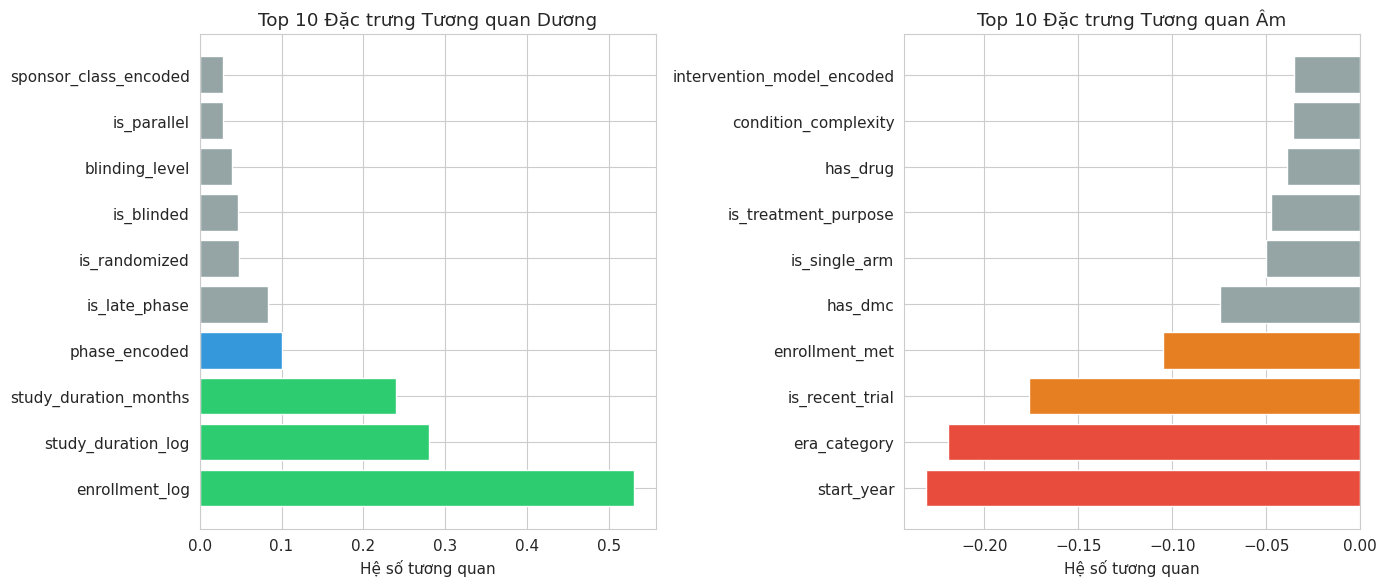

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_positive = correlations.nlargest(10)
ax1 = axes[0]
colors1 = ['#2ecc71' if x > 0.2 else '#3498db' if x > 0.1 else '#95a5a6' for x in top_positive.values]
bars1 = ax1.barh(range(len(top_positive)), top_positive.values, color=colors1)
ax1.set_yticks(range(len(top_positive)))
ax1.set_yticklabels(top_positive.index)
ax1.set_xlabel('Hệ số tương quan')
ax1.set_title('Top 10 Đặc trưng Tương quan Dương')
ax1.axvline(x=0, color='black', linewidth=0.5)

top_negative = correlations.nsmallest(10)
ax2 = axes[1]
colors2 = ['#e74c3c' if x < -0.2 else '#e67e22' if x < -0.1 else '#95a5a6' for x in top_negative.values]
bars2 = ax2.barh(range(len(top_negative)), top_negative.values, color=colors2)
ax2.set_yticks(range(len(top_negative)))
ax2.set_yticklabels(top_negative.index)
ax2.set_xlabel('Hệ số tương quan')
ax2.set_title('Top 10 Đặc trưng Tương quan Âm')
ax2.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
# plt.savefig(FIGURES_DIR / 'feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
# print(f"\nĐã lưu biểu đồ tại: {FIGURES_DIR / 'feature_correlations.png'}")

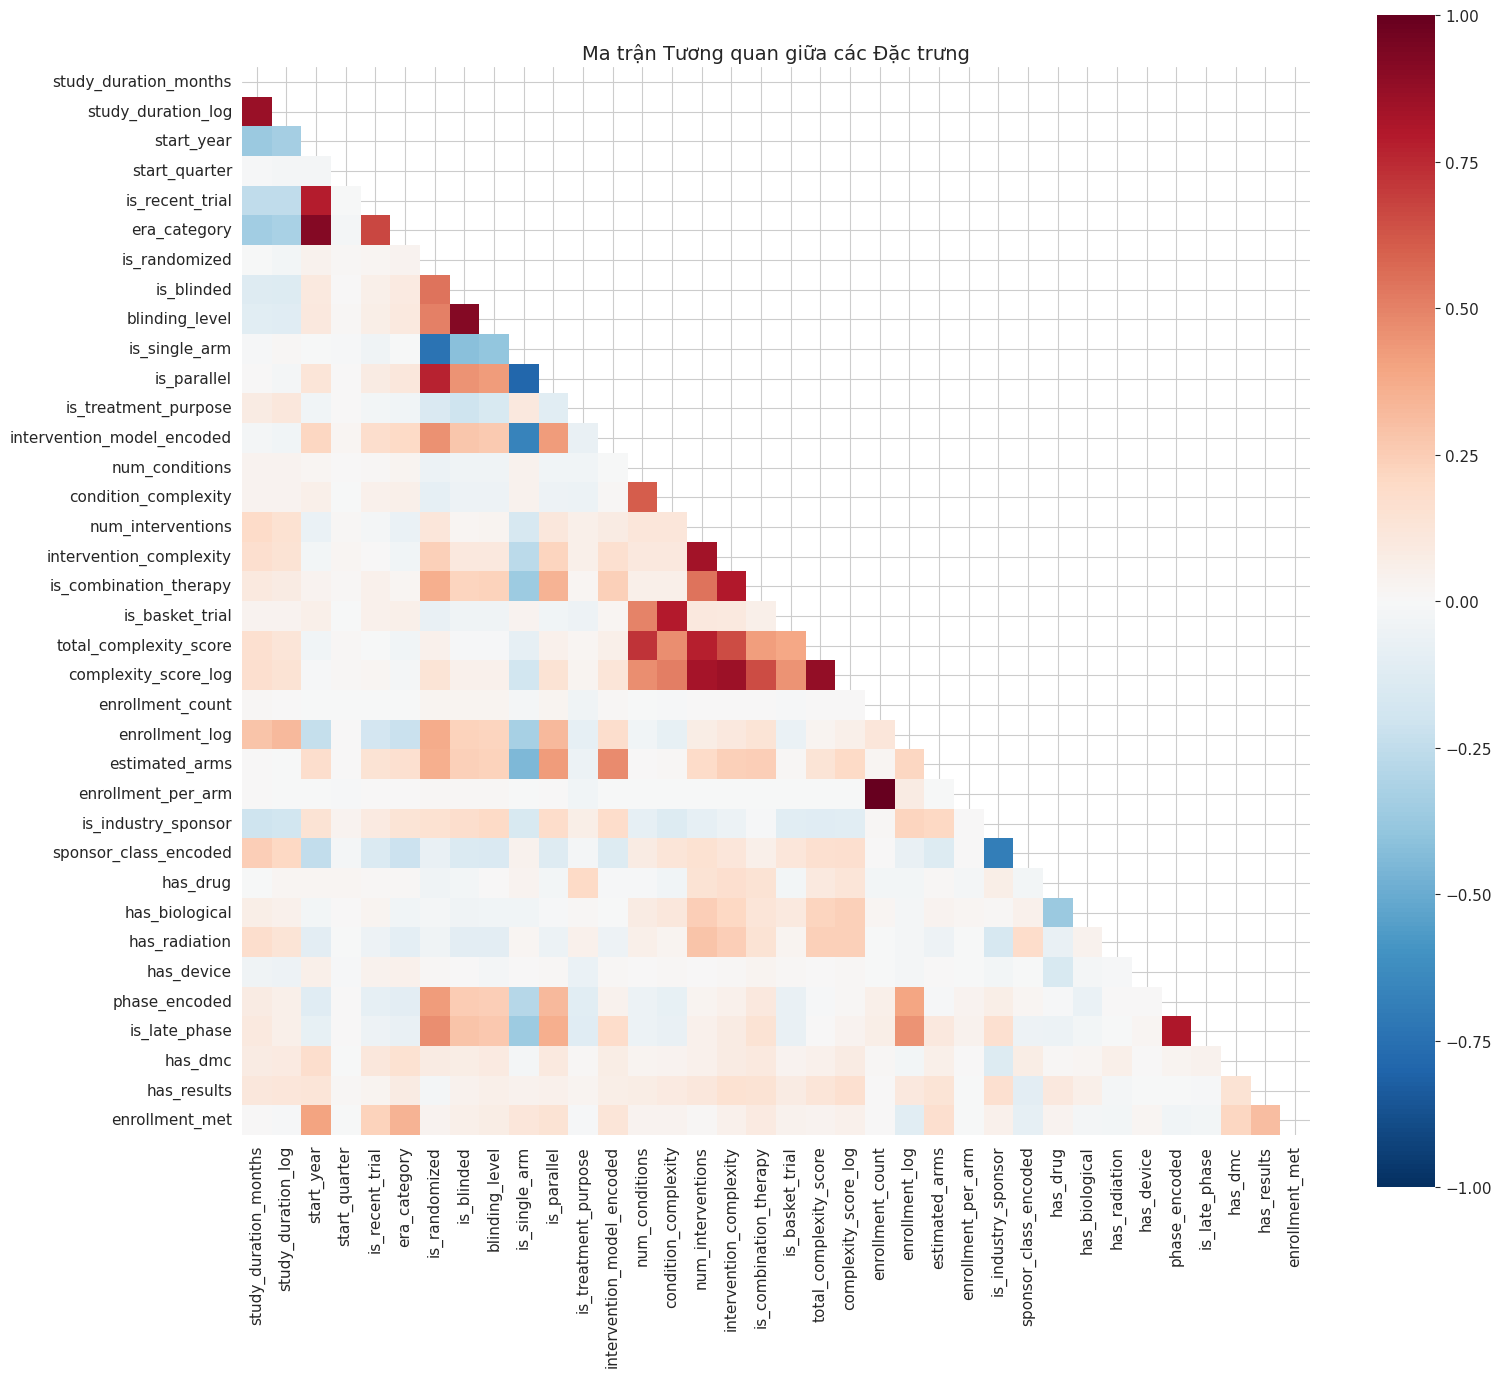

In [10]:
corr_matrix = X_train_scaled.corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Ma trận Tương quan giữa các Đặc trưng', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("PHÂN TÍCH ĐA CỘNG TUYẾN")

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Đặc trưng 1': corr_matrix.columns[i],
                'Đặc trưng 2': corr_matrix.columns[j],
                'Tương quan': f"{corr_matrix.iloc[i, j]:.4f}"
            })

if high_corr_pairs:
    print(f"\nCÁC CẶP ĐẶC TRƯNG CÓ TƯƠNG QUAN CAO (|r| > 0.8):")
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string(index=False))
    print(f"\nTổng cộng {len(high_corr_pairs)} cặp đặc trưng có tương quan cao")
else:
    print("\nKhông có cặp đặc trưng nào có tương quan quá cao (|r| > 0.8)")

PHÂN TÍCH ĐA CỘNG TUYẾN

CÁC CẶP ĐẶC TRƯNG CÓ TƯƠNG QUAN CAO (|r| > 0.8):
            Đặc trưng 1             Đặc trưng 2 Tương quan
  study_duration_months      study_duration_log     0.8608
             start_year            era_category     0.9202
             is_blinded          blinding_level     0.9182
      num_interventions intervention_complexity     0.8423
      num_interventions    complexity_score_log     0.8358
intervention_complexity    complexity_score_log     0.8525
 total_complexity_score    complexity_score_log     0.8789
       enrollment_count      enrollment_per_arm     0.9934
          phase_encoded           is_late_phase     0.8086

Tổng cộng 9 cặp đặc trưng có tương quan cao


## 6. Lưu trữ Dữ liệu và Tham số

Các file được lưu:
- `train_features.csv`, `val_features.csv`, `test_features.csv`: Dữ liệu đã chuẩn hóa
- `feature_scaler.pkl`: Scaler đã fit trên tập train
- `fe_params.json`: Tham số Feature Engineering

In [12]:
print("LƯU TRỮ DỮ LIỆU VÀ THAM SỐ")

train_output = X_train_scaled.copy()
train_output['label_binary'] = y_train.values
train_output['nct_id'] = train_fe['nct_id'].values

val_output = X_val_scaled.copy()
val_output['label_binary'] = y_val.values
val_output['nct_id'] = val_fe['nct_id'].values

test_output = X_test_scaled.copy()
test_output['label_binary'] = y_test.values
test_output['nct_id'] = test_fe['nct_id'].values

print("\n1. LƯU CÁC FILE DỮ LIỆU:")
train_output.to_csv(MODELING_DIR / 'train_features.csv', index=False)
print(f"   Đã lưu: train_features.csv ({len(train_output):,} mẫu, {len(train_output.columns)} cột)")

val_output.to_csv(MODELING_DIR / 'val_features.csv', index=False)
print(f"   Đã lưu: val_features.csv ({len(val_output):,} mẫu, {len(val_output.columns)} cột)")

test_output.to_csv(MODELING_DIR / 'test_features.csv', index=False)
print(f"   Đã lưu: test_features.csv ({len(test_output):,} mẫu, {len(test_output.columns)} cột)")

print("\n2. LƯU SCALER:")
scaler.save(MODELING_DIR / 'feature_scaler.pkl')
print(f"   Đã lưu: feature_scaler.pkl")

print("\n3. LƯU THAM SỐ FEATURE ENGINEERING:")
fe.save_params(MODELING_DIR / 'fe_params.json')
print(f"   Đã lưu: fe_params.json")

LƯU TRỮ DỮ LIỆU VÀ THAM SỐ

1. LƯU CÁC FILE DỮ LIỆU:
   Đã lưu: train_features.csv (21,000 mẫu, 38 cột)
   Đã lưu: val_features.csv (3,000 mẫu, 38 cột)
   Đã lưu: test_features.csv (6,000 mẫu, 38 cột)

2. LƯU SCALER:
   Đã lưu: feature_scaler.pkl

3. LƯU THAM SỐ FEATURE ENGINEERING:
   Đã lưu: fe_params.json


In [13]:
print("LƯU FEATURE DICTIONARY")

feature_dictionary = {
    'metadata': {
        'created_at': datetime.now().isoformat(),
        'total_features': len(feature_list),
        'scaler_type': 'StandardScaler'
    },
    'feature_groups': {
        'temporal': {
            'description': 'Đặc trưng thời gian',
            'features': ['study_duration_months', 'study_duration_log', 'start_year', 
                        'start_quarter', 'is_recent_trial', 'era_category']
        },
        'design': {
            'description': 'Đặc trưng thiết kế nghiên cứu',
            'features': ['is_randomized', 'is_blinded', 'blinding_level', 'is_single_arm',
                        'is_parallel', 'is_treatment_purpose', 'intervention_model_encoded']
        },
        'complexity': {
            'description': 'Đặc trưng độ phức tạp',
            'features': ['num_conditions', 'condition_complexity', 'num_interventions',
                        'intervention_complexity', 'is_combination_therapy', 'is_basket_trial',
                        'total_complexity_score', 'complexity_score_log']
        },
        'scale': {
            'description': 'Đặc trưng quy mô',
            'features': ['enrollment_count', 'enrollment_log', 'estimated_arms', 'enrollment_per_arm']
        },
        'sponsor': {
            'description': 'Đặc trưng nhà tài trợ',
            'features': ['is_industry_sponsor', 'sponsor_class_encoded']
        },
        'intervention': {
            'description': 'Đặc trưng can thiệp',
            'features': ['has_drug', 'has_biological', 'has_radiation', 'has_device']
        },
        'phase': {
            'description': 'Đặc trưng giai đoạn',
            'features': ['phase_encoded', 'is_late_phase']
        },
        'quality': {
            'description': 'Đặc trưng chất lượng',
            'features': ['has_dmc', 'has_results', 'enrollment_met']
        }
    },
    'target': {
        'name': 'label_binary',
        'description': 'Biến mục tiêu (1: Thành công, 0: Thất bại)'
    }
}

with open(MODELING_DIR / 'feature_dictionary_updated.json', 'w', encoding='utf-8') as f:
    json.dump(feature_dictionary, f, indent=2, ensure_ascii=False)

print(f"\nĐã lưu: feature_dictionary_updated.json")

LƯU FEATURE DICTIONARY

Đã lưu: feature_dictionary_updated.json


## 7. Tổng kết và Kết luận

In [14]:
print("TỔNG KẾT FEATURE ENGINEERING")
print("="*60)

print("\n1. SỐ LIỆU DỮ LIỆU:")
print(f"   - Tập Train:      {len(train_output):,} mẫu")
print(f"   - Tập Validation: {len(val_output):,} mẫu")
print(f"   - Tập Test:       {len(test_output):,} mẫu")

print("\n2. ĐẶC TRƯNG ĐÃ TẠO:")
print(f"   - Tổng số đặc trưng: {len(feature_list)}")
print(f"   - Nhóm Temporal:    6 đặc trưng")
print(f"   - Nhóm Design:      7 đặc trưng")
print(f"   - Nhóm Complexity:  8 đặc trưng")
print(f"   - Nhóm Scale:       4 đặc trưng")
print(f"   - Nhóm Sponsor:     2 đặc trưng")
print(f"   - Nhóm Intervention: 4 đặc trưng")
print(f"   - Nhóm Phase:       2 đặc trưng")
print(f"   - Nhóm Quality:     3 đặc trưng")

print("\n3. TOP 5 ĐẶC TRƯNG QUAN TRỌNG NHẤT:")
for i, (feat, corr) in enumerate(correlations.head(5).items(), 1):
    print(f"   {i}. {feat}: r = {corr:.4f}")

print("\n4. CÁC FILE ĐÃ LƯU:")
print(f"   - train_features.csv")
print(f"   - val_features.csv")
print(f"   - test_features.csv")
print(f"   - feature_scaler.pkl")
print(f"   - fe_params.json")
print(f"   - feature_dictionary_updated.json")

print("\n" + "="*60)
print("HOÀN THÀNH FEATURE ENGINEERING!")
print("Dữ liệu đã sẵn sàng cho bước Model Training.")
print("="*60)

TỔNG KẾT FEATURE ENGINEERING

1. SỐ LIỆU DỮ LIỆU:
   - Tập Train:      21,000 mẫu
   - Tập Validation: 3,000 mẫu
   - Tập Test:       6,000 mẫu

2. ĐẶC TRƯNG ĐÃ TẠO:
   - Tổng số đặc trưng: 36
   - Nhóm Temporal:    6 đặc trưng
   - Nhóm Design:      7 đặc trưng
   - Nhóm Complexity:  8 đặc trưng
   - Nhóm Scale:       4 đặc trưng
   - Nhóm Sponsor:     2 đặc trưng
   - Nhóm Intervention: 4 đặc trưng
   - Nhóm Phase:       2 đặc trưng
   - Nhóm Quality:     3 đặc trưng

3. TOP 5 ĐẶC TRƯNG QUAN TRỌNG NHẤT:
   1. enrollment_log: r = 0.5302
   2. study_duration_log: r = 0.2805
   3. study_duration_months: r = 0.2392
   4. start_year: r = -0.2312
   5. era_category: r = -0.2195

4. CÁC FILE ĐÃ LƯU:
   - train_features.csv
   - val_features.csv
   - test_features.csv
   - feature_scaler.pkl
   - fe_params.json
   - feature_dictionary_updated.json

HOÀN THÀNH FEATURE ENGINEERING!
Dữ liệu đã sẵn sàng cho bước Model Training.


### Kết luận

Notebook này đã hoàn thành việc tạo đặc trưng cho mô hình dự đoán thất bại nghiên cứu lâm sàng với các điểm chính:

**Quy trình thực hiện:**
1. Sử dụng module `src.data.feature_engineering` với 2 class `FeatureEngineer` và `FeatureScaler`
2. Tuân thủ nguyên tắc `fit` trên train, `transform` trên val/test để tránh data leakage
3. Tạo 36 đặc trưng chia thành 8 nhóm có ý nghĩa về mặt nghiệp vụ

**Phát hiện quan trọng:**
- `enrollment_log` có tương quan mạnh nhất với biến mục tiêu
- Các đặc trưng về quy mô (enrollment) và thời gian (study_duration) là những yếu tố quan trọng

**Bước tiếp theo:**
- Notebook 05: Model Training - Huấn luyện các mô hình Machine Learning